# Venues within a 15-minute walk: H3 hex grid with OSMnx

This notebook:
1. builds an H3 hex grid over the Toronto boundary,
2. loads venues from a point GeoJSON,
3. downloads the OpenStreetMap walking network with **OSMnx**,
4. computes walking times from every venue with a x-minute cutoff,
5. counts how many venues each hex can reach, then exports the result as a GeoJSON.

**Requirements:** `pip install osmnx h3 geopandas scipy folium mapclassify matplotlib`

---

| | |
|---|---|
| **Inputs** | `src/data/geo/toronto-boundary.geo.json` -- Toronto boundary<br>`data/venues/tac-list/current_toronto_arts_locations_eddit.csv` -- all arts locations (lat/lon)<br>OpenStreetMap walking network (downloaded with `osmnx`, cached in `data/mobility/walk-graph/`) |
| **Outputs** | **`src/data/mobility/hex_walk_30min_res9.geo.json`** -- H3 res-9 hexes with `venues_reachable` (number of arts locations within a 30-minute walk); drawn by the "Venues within a 30 minute walk" layer |
| **Run after** | Independent of steps 01-02 (it does not use transit). Needs `pip install osmnx h3 geopandas scipy folium mapclassify matplotlib`. |


## 1. Settings

In [ ]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

# Repo root = nearest parent folder containing package.json, so this notebook runs from any depth.
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "package.json").exists())
DATA = ROOT / "data"                 # raw + intermediate files
SRC_DATA = ROOT / "src" / "data"     # final outputs consumed directly by the web app

BOUNDARY_PATH = SRC_DATA / "geo" / "toronto-boundary.geo.json"
BOUNDARY_NAME = "Toronto"
VENUES_PATH = (DATA / "venues/tac-list/current_toronto_arts_locations_eddit.csv")

df = pd.read_csv(VENUES_PATH)
df = df.dropna(subset=["lat", "lon"])
venues = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=4326
)

GRAPH_CACHE   = DATA / "mobility" / "walk-graph" / "toronto-walk.graphml"   # downloaded OSM walk network (git-ignored)
OUTPUT_DIR    = SRC_DATA / "mobility"                                       # final output: read directly by the web app

H3_RES           = 9     # 9 ~ 175 m hexes, 10 ~ 65 m hexes
MAX_WALK_MIN     = 30   
WALK_SPEED_KMH   = 4.8
NETWORK_BUFFER_M = 1500  # extra network beyond the boundary so edge hexes aren't undercounted
MAX_SNAP_M       = 300   # points farther than this from any street are treated as off-network

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Imports

In [14]:
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import h3
from shapely.geometry import Polygon, Point

ox.settings.use_cache = True   # caches raw Overpass responses too
print("osmnx", ox.__version__, "| h3", h3.__version__, "| geopandas", gpd.__version__)

osmnx 2.1.0 | h3 4.5.0 | geopandas 1.1.3


## 3. Load the boundary

Invalid features before repair: 1
MultiPolygon | metric CRS: EPSG:32617


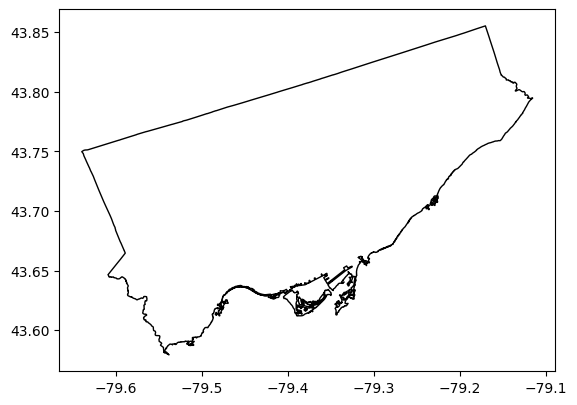

In [ ]:
from shapely import make_valid
from shapely.geometry import MultiPolygon

boundary = gpd.read_file(BOUNDARY_PATH).to_crs(4326)
if BOUNDARY_NAME:
    boundary = boundary[boundary["name"] == BOUNDARY_NAME]
    assert len(boundary) > 0, f"No feature with name == {BOUNDARY_NAME!r}"

print("Invalid features before repair:", (~boundary.is_valid).sum())
boundary["geometry"] = boundary.geometry.apply(make_valid)

# make_valid
def polygons_only(geom):
    if geom.geom_type in ("Polygon", "MultiPolygon"):
        return geom
    parts = [g for g in getattr(geom, "geoms", []) if g.geom_type in ("Polygon", "MultiPolygon")]
    return MultiPolygon([p for g in parts for p in getattr(g, "geoms", [g])])

boundary["geometry"] = boundary.geometry.apply(polygons_only)
boundary_geom = boundary.union_all()
assert boundary_geom.is_valid, "Boundary still invalid after repair"

utm_crs = boundary.estimate_utm_crs()
print(boundary_geom.geom_type, "| metric CRS:", utm_crs.to_string())
boundary.plot(edgecolor="black", facecolor="none");

## 4. Build the H3 hex grid

5,680 hexes at resolution 9


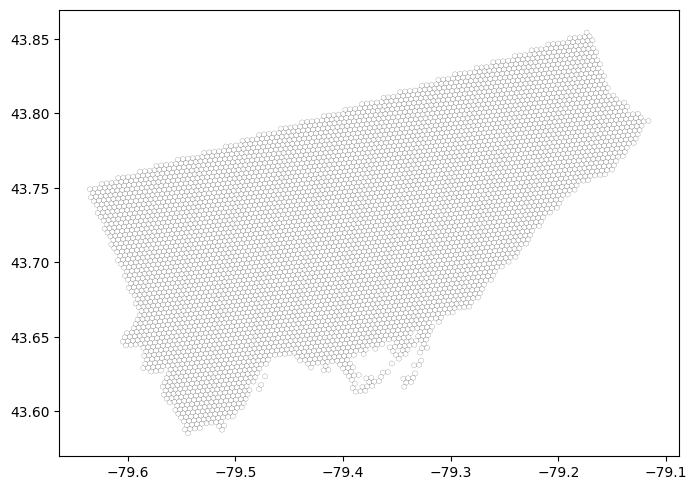

In [16]:
cells = sorted(h3.geo_to_cells(boundary_geom, H3_RES))

def cell_polygon(cell):
    # h3 returns (lat, lng); shapely wants (lng, lat)
    return Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(cell)])

def cell_centroid(cell):
    lat, lng = h3.cell_to_latlng(cell)
    return Point(lng, lat)

hexes = gpd.GeoDataFrame({"id": cells}, geometry=[cell_polygon(c) for c in cells], crs=4326)
hex_points = gpd.GeoDataFrame({"id": cells}, geometry=[cell_centroid(c) for c in cells], crs=4326)
print(f"{len(hexes):,} hexes at resolution {H3_RES}")
hexes.plot(edgecolor="grey", linewidth=0.2, facecolor="none", figsize=(8, 8));

## 5. Load the venues

Venues **outside** the boundary are kept on purpose: a hex near the edge can still reach them on foot.

In [ ]:
df = pd.read_csv(VENUES_PATH)
df = df.dropna(subset=["lat", "lon"])
venues = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df["lon"], df["lat"]), crs=4326
)

venues["id"] = [f"v{i}" for i in range(len(venues))]

assert venues["id"].is_unique, "Venue ids must be unique"
inside = venues.within(boundary_geom).sum()
print(f"{len(venues):,} venues ({inside:,} inside the boundary)")

2,576 venues (2,574 inside the boundary)


## 6. Get the walking network

The first run downloads the network for the boundary plus a buffer from OpenStreetMap, which takes a few minutes for all of Toronto,
and saves it to `GRAPH_CACHE`. Later runs load the saved file in seconds.
**Delete the cached file** if you change the boundary or the buffer, otherwise the old network is reused.

In [18]:
if GRAPH_CACHE.exists():
    print("Loading cached network:", GRAPH_CACHE)
    G = ox.load_graphml(GRAPH_CACHE)
else:
    boundary_buffered = (
        gpd.GeoSeries([boundary_geom], crs=4326)
        .to_crs(utm_crs).buffer(NETWORK_BUFFER_M)
        .to_crs(4326).iloc[0]
    )
    t0 = time.time()
    print("Downloading walking network from OpenStreetMap...")
    G = ox.graph_from_polygon(boundary_buffered, network_type="walk")
    GRAPH_CACHE.parent.mkdir(parents=True, exist_ok=True)
    ox.save_graphml(G, GRAPH_CACHE)
    print(f"Downloaded and saved in {time.time() - t0:.0f} s")

G = ox.project_graph(G, to_crs=utm_crs)   # metres, so snapping distances are meaningful

SPEED_M_PER_MIN = WALK_SPEED_KMH * 1000 / 60
for _, _, data in G.edges(data=True):
    data["walk_min"] = data["length"] / SPEED_M_PER_MIN

print(f"{G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Loading cached network: ../../graphs/toronto/toronto-walk.graphml
222,845 nodes, 612,988 edges


## 7. Snap venues and hex centres to the network

Each point is matched to its nearest street node. The straight-line distance to that node is added to the trip as extra walking time.
Points more than `MAX_SNAP_M` from any street (open water, rail yards, large parks without paths) are left out of the routing.

In [19]:
def snap(points):
    pts = points.to_crs(utm_crs)
    nodes, dists = ox.distance.nearest_nodes(
        G, pts.geometry.x.to_numpy(), pts.geometry.y.to_numpy(), return_dist=True
    )
    return np.asarray(nodes), np.asarray(dists)

venues["node"], venues["snap_m"] = snap(venues)
hex_points["node"], hex_points["snap_m"] = snap(hex_points)

venues_ok = venues[venues["snap_m"] <= MAX_SNAP_M]
hexes_ok = hex_points[hex_points["snap_m"] <= MAX_SNAP_M]

print(f"Venues on network: {len(venues_ok):,} / {len(venues):,}")
print(f"Hexes on network:  {len(hexes_ok):,} / {len(hex_points):,}")
if len(venues_ok) < len(venues):
    print("Off-network venues:", venues.loc[venues["snap_m"] > MAX_SNAP_M, "id"].tolist())

Venues on network: 2,560 / 2,576
Hexes on network:  5,580 / 5,680
Off-network venues: ['v27', 'v28', 'v39', 'v41', 'v45', 'v47', 'v48', 'v49', 'v51', 'v56', 'v62', 'v162', 'v2267', 'v2282', 'v2418', 'v2488']


## 8. Compute walking travel times

Walking time is the same in both directions, so the search runs once **from each venue** with a x-minute cutoff,
which is much faster than searching from every hex. A trip's time is the walk to the street from the venue,
plus the network walk, plus the walk from the street to the hex centre.

In [20]:
hex_snap_min = dict(zip(hexes_ok["id"], hexes_ok["snap_m"] / SPEED_M_PER_MIN))
node_to_hexes = hexes_ok.groupby("node")["id"].apply(list).to_dict()

rows = []
t0 = time.time()
for i, (vid, vnode, vsnap_m) in enumerate(zip(venues_ok["id"], venues_ok["node"], venues_ok["snap_m"]), 1):
    access_min = vsnap_m / SPEED_M_PER_MIN
    budget = MAX_WALK_MIN - access_min
    if budget <= 0:
        continue
    reached = nx.single_source_dijkstra_path_length(G, vnode, cutoff=budget, weight="walk_min")
    for node, net_min in reached.items():
        for hid in node_to_hexes.get(node, ()):
            total = access_min + net_min + hex_snap_min[hid]
            if total <= MAX_WALK_MIN:
                rows.append((vid, hid, total))
    if i % 100 == 0:
        print(f"  {i:,} / {len(venues_ok):,} venues routed")

ttm = pd.DataFrame(rows, columns=["from_id", "to_id", "travel_time"])  # venue, hex, minutes
print(f"{len(ttm):,} reachable venue–hex pairs in {time.time() - t0:.1f} s")
ttm.head()

  100 / 2,560 venues routed
  200 / 2,560 venues routed
  300 / 2,560 venues routed
  400 / 2,560 venues routed
  500 / 2,560 venues routed
  600 / 2,560 venues routed
  700 / 2,560 venues routed
  800 / 2,560 venues routed
  900 / 2,560 venues routed
  1,000 / 2,560 venues routed
  1,100 / 2,560 venues routed
  1,200 / 2,560 venues routed
  1,300 / 2,560 venues routed
  1,400 / 2,560 venues routed
  1,500 / 2,560 venues routed
  1,600 / 2,560 venues routed
  1,700 / 2,560 venues routed
  1,800 / 2,560 venues routed
  1,900 / 2,560 venues routed
  2,000 / 2,560 venues routed
  2,100 / 2,560 venues routed
  2,200 / 2,560 venues routed
  2,300 / 2,560 venues routed
  2,400 / 2,560 venues routed
  2,500 / 2,560 venues routed
203,650 reachable venue–hex pairs in 30.4 s


,from_id,to_id,travel_time
0,v0,892b9bcea6fffff,6.519627
1,v0,892b9bccc9bffff,10.523289
2,v0,892b9bcea63ffff,10.527529
3,v0,892b9bcea67ffff,13.521274
4,v0,892b9bcea77ffff,16.955717


## 9. Count venues reachable from each hex

In [21]:
per_hex = (
    ttm.groupby("to_id")
    .agg(venues_reachable=("from_id", "nunique"),
         nearest_venue_min=("travel_time", "min"))
    .rename_axis("id")
    .reset_index()
)

hexes = hexes[["id", "geometry"]].merge(per_hex, on="id", how="left")
hexes["venues_reachable"] = hexes["venues_reachable"].fillna(0).astype(int)
hexes["nearest_venue_min"] = hexes["nearest_venue_min"].round(1)
hexes["on_network"] = hexes["id"].isin(hexes_ok["id"])
hexes.describe()

,venues_reachable,nearest_venue_min
count,5680.000000,5464.000000
mean,35.853873,8.676574
std,64.372177,5.399421
min,0.000000,0.200000
25%,9.000000,4.600000
50%,17.000000,7.700000
75%,29.000000,11.600000
max,484.000000,30.000000


In [22]:
venue_hex = gpd.sjoin(
    venues[["id", "node", "snap_m", "geometry"]],
    hexes[["id", "venues_reachable", "on_network", "geometry"]].rename(columns={"id": "hex_id"}),
    predicate="within",
)
problems = venue_hex[venue_hex["venues_reachable"] == 0]
print(f"{len(problems)} venues sit in a hex showing 0")

hp = hex_points.set_index("id")
routed = set(venues_ok["id"])
for _, r in problems.head(10).iterrows():
    h = hp.loc[r["hex_id"]]
    try:
        t = round(nx.shortest_path_length(G, r["node"], h["node"], weight="walk_min"), 1)
    except nx.NetworkXNoPath:
        t = "no path"
    print(f"{r['id']}: venue snap {r['snap_m']:.0f} m, hex snap {h['snap_m']:.0f} m, "
          f"on_network={r['on_network']}, venue routed={r['id'] in routed}, network walk={t} min")

15 venues sit in a hex showing 0
v27: venue snap 2417 m, hex snap 2260 m, on_network=False, venue routed=False, network walk=6.5 min
v28: venue snap 2290 m, hex snap 2260 m, on_network=False, venue routed=False, network walk=0 min
v39: venue snap 2008 m, hex snap 2049 m, on_network=False, venue routed=False, network walk=0 min
v41: venue snap 2054 m, hex snap 2138 m, on_network=False, venue routed=False, network walk=0 min
v47: venue snap 1378 m, hex snap 1347 m, on_network=False, venue routed=False, network walk=113.0 min
v48: venue snap 1529 m, hex snap 1617 m, on_network=False, venue routed=False, network walk=0 min
v49: venue snap 1162 m, hex snap 1347 m, on_network=False, venue routed=False, network walk=0 min
v56: venue snap 821 m, hex snap 672 m, on_network=False, venue routed=False, network walk=0 min
v326: venue snap 164 m, hex snap 317 m, on_network=False, venue routed=True, network walk=5.4 min
v1570: venue snap 14 m, hex snap 32 m, on_network=True, venue routed=True, networ

## 10. Summary: how many hexes reach N venues

Counts only hexes on the walking network. Area assumes equal-size cells at this resolution.

In [23]:
cell_area_km2 = h3.average_hexagon_area(H3_RES, unit="km^2")
on_net = hexes[hexes["on_network"]]

summary = (
    on_net["venues_reachable"].value_counts().sort_index()
    .rename_axis("venues_reachable").reset_index(name="hex_count")
)
summary["approx_area_km2"] = (summary["hex_count"] * cell_area_km2).round(2)
summary["share_of_hexes_%"] = (100 * summary["hex_count"] / len(on_net)).round(1)
summary["hexes_with_at_least_N"] = summary["hex_count"][::-1].cumsum()[::-1]
summary

,venues_reachable,hex_count,approx_area_km2,share_of_hexes_%,hexes_with_at_least_N
0,0,116,12.22,2.1,5580
1,1,97,10.22,1.7,5464
2,2,111,11.69,2.0,5367
3,3,96,10.11,1.7,5256
4,4,163,17.17,2.9,5160
...,...,...,...,...,...
342,464,1,0.11,0.0,6
343,467,1,0.11,0.0,5
344,472,1,0.11,0.0,4
345,482,2,0.21,0.0,3


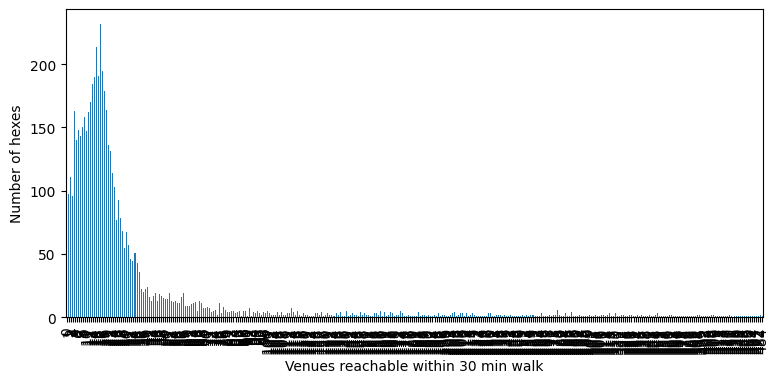

In [24]:
ax = summary.plot.bar(x="venues_reachable", y="hex_count", legend=False, figsize=(9, 4))
ax.set_xlabel(f"Venues reachable within {MAX_WALK_MIN} min walk")
ax.set_ylabel("Number of hexes");

In [25]:
out_path = OUTPUT_DIR / f"hex_walk_{MAX_WALK_MIN}min_res{H3_RES}.geo.json"
hexes.to_file(out_path, driver="GeoJSON")
print(f"Saved {len(hexes):,} hexes to {out_path.resolve()}")

Saved 5,680 hexes to /Users/scottmccallum/Documents/School of Cities/GitHub/schoolofcities/eddit-tac/analysis/mobility/output/hex_walk_30min_res9.geojson
